# imports

In [1]:
# verify version
import sys
assert sys.version.split('.')[0] == '3'
!which python

/Users/andreassteiner/git/rizhom/env/bin/python


In [8]:
from matplotlib import pyplot as plt
import numpy as np
import numpy
import scipy.io.wavfile

import pyaudio
import aubio
# import bob.ap

# provides record(), playback()
%run -i lib/audio.py
# provides log_mel_spectrogram()
%run -i ../py/features.py
# provides rate, buf_size, hop_size, to_string(), ...
%run -i ../py/settings.py
# provides int16_to_float()
%run -i ../py/util.py

In [5]:
# Using interface `0` by default.
p = pyaudio.PyAudio()
for i in range(p.get_device_count()):#list all available audio devices
    dev = p.get_device_info_by_index(i)
    print((i, dev['name'], dev['maxInputChannels']))

(0, 'Built-in Microphone', 2)
(1, 'Built-in Output', 0)
(2, 'iShowU Audio Capture', 2)
(3, 'Multi-Output Device', 0)


# record

In [9]:
to_string()

'rate=16000 buf_secs=0.064s (1024) hop_secs=0.032s (512) '

In [15]:
# record ...
data = record(secs=7, rate=rate)
plt.plot(data)
len(data), len(data)/rate

TypeError: argument 3 must be int, not str

In [55]:
# store recording...
scipy.io.wavfile.write('../recordings/tmp.wav', rate, data)
!ls -lh ../recordings/*

-rw-r--r--  1 andreassteiner  staff   218K Apr  7 09:37 ../recordings/a_welle.wav


In [33]:
# ...load recording
sr, data = scipy.io.wavfile.read('../recordings/a_welle.wav')
sr, len(data), len(data)/sr, data.min(), data.max()

(16000, 111616, 6.976, -10038, 12440)

# analyze

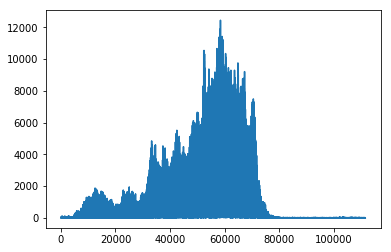

In [10]:
# simply take amplitude for loudness
plt.plot(np.abs(data))

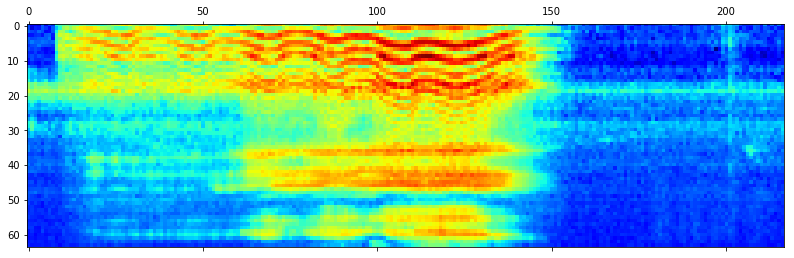

In [11]:
# show log mel spectrogram
# -> note harmonics
import functools
lms = functools.partial(
    log_mel_spectrogram,
    audio_sample_rate=rate,
    window_length_secs=buf_size/rate,
    hop_length_secs=hop_size/rate,
)
logmel = lms(data)
plt.matshow(logmel.T, cmap='jet')

## streaming implementation

In [40]:
# imports OutlierFilter, MovingAverage, EnvelopAverager
%run ../py/streaming.py

In [12]:
OutlierFilter(d=10, n=1)([100, 100, 101, 102, 0, 105])

array([  0, 100, 101, 102, 102, 102])

In [13]:
MovingAverage(n=2)([0, 1, 2, 2])

array([0. , 0.5, 1. , 1. ])

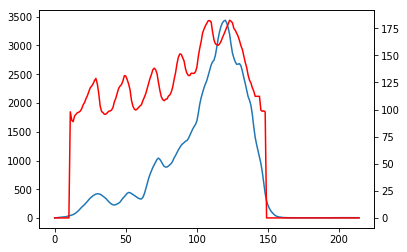

In [15]:
pitcher = aubio.pitch(method='yinfft', buf_size=buf_size, hop_size=hop_size, samplerate=rate)
pitcher.set_unit('Hz')
pitcher.set_tolerance(0.8)

outlier_filter = OutlierFilter(d=100, n=2)
envelop_averager = EnvelopAverager(buf_size=buf_size, n=10)

pitches = []
louds = []
for i in range(data.shape[0] // hop_size - buf_size // hop_size - 1):
    pitch = pitcher(int16_to_float(data[i*hop_size:(i+1)*hop_size]))[0]
    pitch = outlier_filter(pitch)
    pitches.append(pitch)
    loud = envelop_averager(data[i*hop_size:i*hop_size+buf_size])
    louds.append(loud)

plt.plot(louds)
plt.twinx()
plt.plot(pitches, 'r');

(0.9, 3.1)

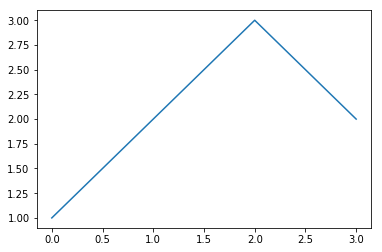

In [54]:
plt.plot([1, 2, 3, 2])
plt.gca().get_ylim()

## original implementation

(64, 217)


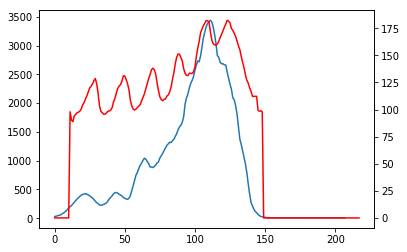

In [16]:
def moving_average(a, n=3) :
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:] / n

def binned_average(data, n):
    w = data.shape[0] // n
    data = data[:n*w]
    data = np.reshape(data, (n, w))
    return np.mean(data, axis=1)

def get_pitch(data, method='yinfft', tolerance=0.8):
    data_float = (data / 2**15).astype(np.float32)
    pitch_detector = aubio.pitch(method=method, buf_size=buf_size, hop_size=hop_size, samplerate=rate)
    pitch_detector.set_unit('Hz')
    pitch_detector.set_tolerance(tolerance)
    return [
        pitch_detector(data_float[i*hop_size:(i+1)*hop_size])[0]
        for i in range(data.shape[0]//hop_size)
    ]

def filter_outliers(vs, d=100, n=2):
    return list(OutlierFilter(d=d, n=n)(vs))

x = logmel.T
print(x.shape)
plt.plot()
# loudness in blue
plt.plot(moving_average(binned_average(np.abs(data), n=x.shape[1]), n=10))
plt.gca().twinx()
# pitch in red
plt.plot(filter_outliers(get_pitch(data)), 'r')

[]

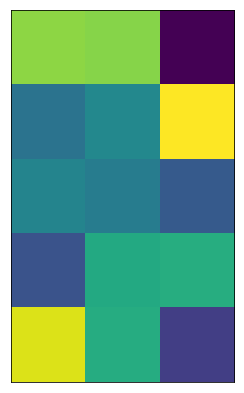

In [27]:
x = np.random.normal(size=(5, 3))
t = plt.matshow(x)
a = plt.gca()
a.set_xticks([])
a.set_yticks([])

In [32]:
import glob, os

os.listdir('.')
glob.glob('{}/*.wav'.format(os.path.dirname(__file__)))

[]

In [21]:
t()